In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

In [3]:
DATA_FILE = "../../data/processed/cardio_onc_prostate_06_broad_clean.csv"
OUT_DIR = "Results/ElasticNet"
SEED = 42

os.makedirs(OUT_DIR, exist_ok = True)

df = pd.read_csv(DATA_FILE)

df["at_risk"] = (
    (df["bp_meds_post_binary"] == 1) |
    (df["lipid_meds_post_binary"] == 1) |
    (df["dm_meds_post_binary"] == 1)
).astype(int)

# Risk Visuals

### BP Meds Prior

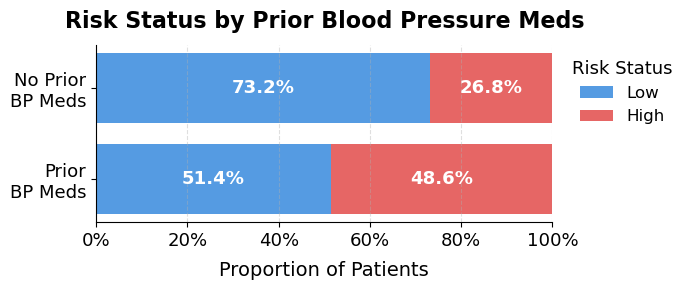

In [6]:
bp_labels = {1: 'Prior BP Meds', 0: 'No Prior BP Meds'}
df['bp_meds_label'] = df['bp_meds_prior'].map(bp_labels)

risk_labels = {0: 'Low', 1: 'High'}
df['risk_label'] = df['at_risk'].map(risk_labels)

risk_groups = ['Low', 'High']
colors = ['#378ADD', '#E24B4A']

y_cats = ['Prior BP Meds', 'No Prior BP Meds']
y_pos = [0, 0.45]

prop_data = {}
for cat in y_cats:
    subset = df[df['bp_meds_label'] == cat]
    total = len(subset)
    prop_data[cat] = {risk: (subset['risk_label'] == risk).sum() / total * 100
                      for risk in risk_groups}

fig, ax = plt.subplots(figsize=(7, 3))

lefts = np.zeros(len(y_cats))
for i, risk in enumerate(risk_groups):
    values = [prop_data[cat][risk] for cat in y_cats]
    bars = ax.barh(y_pos, values, left=lefts, color=colors[i],
                   alpha=0.85, label=str(risk), height=0.35)

    for bar, val in zip(bars, values):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=13, color='white', fontweight='bold')  # ← up from 10
    lefts += values

ax.set_xlim(0, 100)
ax.set_yticks(y_pos)
ax.set_yticklabels(['Prior\nBP Meds', 'No Prior\nBP Meds'], fontsize=13)  # ← two lines, larger
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', labelsize=13)  # ← x-axis tick font
ax.set_xlabel('Proportion of Patients', fontsize=14, labelpad=8)  # ← up from 12
ax.set_title('Risk Status by Prior Blood Pressure Meds', fontsize=16,  # ← up from 14
             fontweight='bold', pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(title='Risk Status', fontsize=12, title_fontsize=13,  # ← explicit legend fonts
          frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [48]:
pd.crosstab(df['bp_meds_label'], df['risk_label'])

risk_label,High,Low
bp_meds_label,,
No Prior BP Meds,22,60
Prior BP Meds,34,36


### Lipid Panel Checked

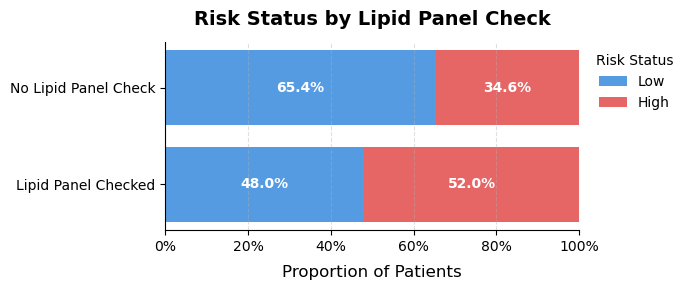

In [ ]:
lipid_labels = {1: 'Lipid Panel Checked', 0: 'No Lipid Panel Check'}
df['lipid_label'] = df['lipid_panel_checked'].map(lipid_labels)

risk_labels = {0: 'Low', 1: 'High'}
df['risk_label'] = df['at_risk'].map(risk_labels)

risk_groups = ['Low', 'High']
colors = ['#378ADD', '#E24B4A']

y_cats = ['Lipid Panel Checked', 'No Lipid Panel Check']
y_pos = [0, 0.45]

prop_data = {}

for cat in y_cats:
    subset = df[df['lipid_label'] == cat]
    total = len(subset)

    prop_data[cat] = {
        risk: (subset['risk_label'] == risk).sum() / total * 100
        for risk in risk_groups
    }

fig, ax = plt.subplots(figsize=(7, 3))

lefts = np.zeros(len(y_cats))

for i, risk in enumerate(risk_groups):

    values = [prop_data[cat][risk] for cat in y_cats]

    bars = ax.barh(
        y_pos,
        values,
        left=lefts,
        color=colors[i],
        alpha=0.85,
        label=str(risk),
        height=0.35
    )

    for bar, val in zip(bars, values):

        if val > 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%',
                ha='center',
                va='center',
                fontsize=10,
                color='white',
                fontweight='bold'
            )

    lefts += values

ax.set_xlim(0, 100)

ax.set_yticks(y_pos)
ax.set_yticklabels(y_cats)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0f}%')
)

ax.set_xlabel('Proportion of Patients', fontsize=12, labelpad=8)

ax.set_title(
    'Risk Status by Lipid Panel Check',
    fontsize=14,
    fontweight='bold',
    pad=12
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.legend(
    title='Risk Status',
    frameon=False,
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

In [69]:
pd.crosstab(df['lipid_label'], df['risk_label'])

risk_label,High,Low
lipid_label,,
Lipid Panel Checked,26,24
No Lipid Panel Check,53,100


### DM Noninsulin

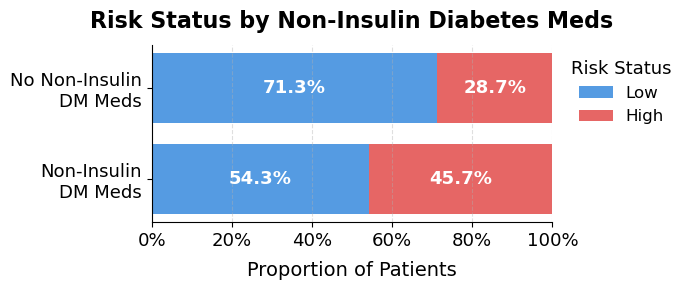

In [7]:
dm_labels = {1: 'Non-Insulin DM Meds', 0: 'No Non-Insulin DM Meds'}
df['dm_meds_label'] = df['dm_noninsulin'].map(dm_labels)

risk_labels = {0: 'Low', 1: 'High'}
df['risk_label'] = df['at_risk'].map(risk_labels)

risk_groups = ['Low', 'High']
colors = ['#378ADD', '#E24B4A']

y_cats = ['Non-Insulin DM Meds', 'No Non-Insulin DM Meds']
y_pos = [0, 0.45]

prop_data = {}
for cat in y_cats:
    subset = df[df['dm_meds_label'] == cat]
    total = len(subset)
    prop_data[cat] = {risk: (subset['risk_label'] == risk).sum() / total * 100
                      for risk in risk_groups}

fig, ax = plt.subplots(figsize=(7, 3))

lefts = np.zeros(len(y_cats))
for i, risk in enumerate(risk_groups):
    values = [prop_data[cat][risk] for cat in y_cats]
    bars = ax.barh(y_pos, values, left=lefts, color=colors[i],
                   alpha=0.85, label=str(risk), height=0.35)

    for bar, val in zip(bars, values):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=13, color='white', fontweight='bold')  # ← up from 10
    lefts += values

ax.set_xlim(0, 100)
ax.set_yticks(y_pos)
ax.set_yticklabels(['Non-Insulin\nDM Meds', 'No Non-Insulin\nDM Meds'], fontsize=13)  # ← two lines, larger
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', labelsize=13)  # ← x-axis tick font
ax.set_xlabel('Proportion of Patients', fontsize=14, labelpad=8)  # ← up from 12
ax.set_title('Risk Status by Non-Insulin Diabetes Meds', fontsize=16,  # ← up from 14
             fontweight='bold', pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(title='Risk Status', fontsize=12, title_fontsize=13,  # ← explicit legend fonts
          frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [71]:
pd.crosstab(df['dm_meds_label'], df['risk_label'])

risk_label,High,Low
dm_meds_label,,
No Non-Insulin DM Meds,37,92
Non-Insulin DM Meds,16,19


# NHT Choice Visuals

### Age

C:\Users\Trian\AppData\Local\Temp\ipykernel_28960\1483155072.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


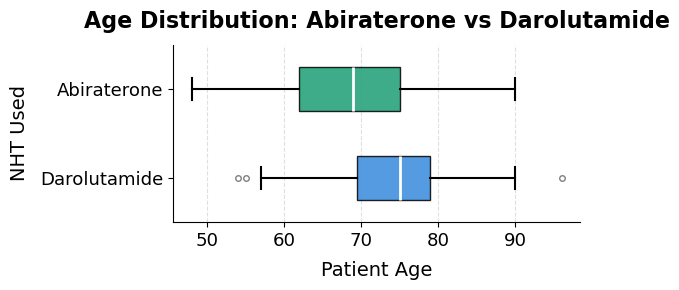

In [10]:
groups = ["Darolutamide", "Abiraterone"]
data_by_group = [df[df['specific_nht_used'] == g]['age'].dropna() for g in groups]

fig, ax = plt.subplots(figsize=(6, 3))

bp = ax.boxplot(
    data_by_group,
    labels=groups,
    vert=False,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none')
)

colors = ['#378ADD', '#1D9E75']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_xlabel('Patient Age', fontsize=14, labelpad=8)          # ← up from 12
ax.set_ylabel('NHT Used', fontsize=14, labelpad=8)             # ← up from 12
ax.set_title('Age Distribution: Abiraterone vs Darolutamide',
             fontsize=16, fontweight='bold', pad=12)           # ← up from 14
ax.tick_params(axis='both', labelsize=13)                      # ← x and y tick fonts

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


# ADT Choice Visuals

### SBP and Orgovyx

C:\Users\Trian\AppData\Local\Temp\ipykernel_28960\4002469235.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


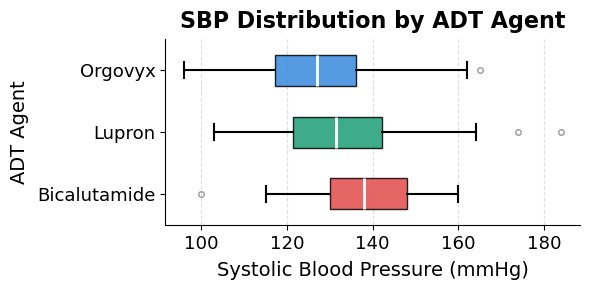

In [11]:
groups = ['Orgovyx', 'Lupron', 'Bicalutamide']
data_by_group = [df[df['adt_agent'] == g]['sbp'].dropna() for g in groups]

fig, ax = plt.subplots(figsize=(6, 3))

bp = ax.boxplot(
    data_by_group,
    labels=groups,
    vert=False,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.4, linestyle='none')
)

colors = ['#378ADD', '#1D9E75', '#E24B4A']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.invert_yaxis()

ax.set_xlabel('Systolic Blood Pressure (mmHg)', fontsize=14, labelpad=6)  # ← up from 10
ax.set_ylabel('ADT Agent', fontsize=14, labelpad=6)                        # ← up from 12
ax.set_title('SBP Distribution by ADT Agent',
             fontsize=16, fontweight='bold', pad=8)                        # ← up from 14
ax.tick_params(axis='both', labelsize=13)                                  # ← x and y tick fonts

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [64]:
df["adt_agent"].value_counts()

adt_agent
Orgovyx         83
Lupron          66
Bicalutamide    27
Firmagon        19
Name: count, dtype: int64

# Referral Gaps

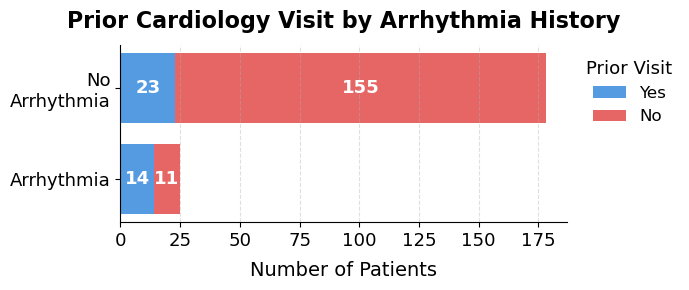

In [8]:
arrhythmia_labels = {1: 'Arrhythmia', 0: 'No Arrhythmia'}
df['arrhythmia_label'] = df['hx_arrhythmia'].map(arrhythmia_labels)

cards_labels = {1: 'Yes', 0: 'No'}
df['cards_prior_label'] = df['cards_prior'].map(cards_labels)

y_cats = ['Arrhythmia', 'No Arrhythmia']
y_pos = [0, 0.45]
colors = ['#378ADD', '#E24B4A']
cards_groups = ['Yes', 'No']

prop_data = {}
for cat in y_cats:
    subset = df[df['arrhythmia_label'] == cat]
    prop_data[cat] = {cards: (subset['cards_prior_label'] == cards).sum()
                      for cards in cards_groups}

fig, ax = plt.subplots(figsize=(7, 3))

lefts = np.zeros(len(y_cats))
for i, cards in enumerate(cards_groups):
    values = [prop_data[cat][cards] for cat in y_cats]
    bars = ax.barh(y_pos, values, left=lefts, color=colors[i],
                   alpha=0.85, label=cards, height=0.35)

    for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{int(val)}', ha='center', va='center',
                    fontsize=13, color='white', fontweight='bold')  # ← up from 10
    lefts += values

ax.set_xlim(0, None)
ax.set_yticks(y_pos)
ax.set_yticklabels(['Arrhythmia', 'No\nArrhythmia'], fontsize=13)  # ← two lines, larger
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.tick_params(axis='x', labelsize=13)  # ← x-axis tick font
ax.set_xlabel('Number of Patients', fontsize=14, labelpad=8)  # ← up from 12
ax.set_title('Prior Cardiology Visit by Arrhythmia History', fontsize=16,  # ← up from 14
             fontweight='bold', pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(title='Prior Visit', fontsize=12, title_fontsize=13,  # ← explicit legend fonts
          frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

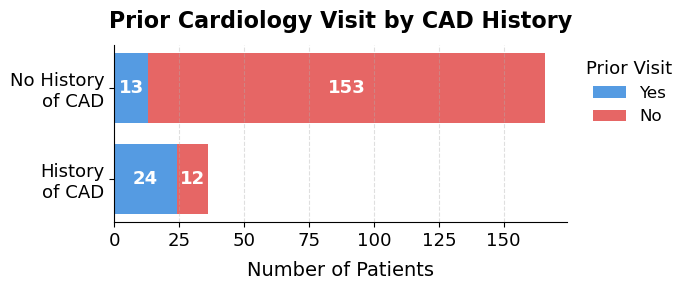

In [9]:
cad_labels = {1: 'History of CAD', 0: 'No History of CAD'}
df['cad_label'] = df['hx_cad'].map(cad_labels)

cards_labels = {1: 'Yes', 0: 'No'}
df['cards_prior_label'] = df['cards_prior'].map(cards_labels)

y_cats = ['History of CAD', 'No History of CAD']
y_pos = [0, 0.45]

colors = ['#378ADD', '#E24B4A']
cards_groups = ['Yes', 'No']

count_data = {}
for cat in y_cats:
    subset = df[df['cad_label'] == cat]
    count_data[cat] = {
        cards: (subset['cards_prior_label'] == cards).sum()
        for cards in cards_groups
    }

fig, ax = plt.subplots(figsize=(7, 3))

lefts = np.zeros(len(y_cats))

for i, cards in enumerate(cards_groups):
    values = [count_data[cat][cards] for cat in y_cats]

    bars = ax.barh(
        y_pos,
        values,
        left=lefts,
        color=colors[i],
        alpha=0.85,
        label=cards,
        height=0.35
    )

    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{int(val)}',
                ha='center',
                va='center',
                fontsize=13,          # ← up from 10
                color='white',
                fontweight='bold'
            )

    lefts += values

ax.set_yticks(y_pos)
ax.set_yticklabels(['History\nof CAD', 'No History\nof CAD'], fontsize=13)  # ← two lines, larger
ax.tick_params(axis='x', labelsize=13)                                       # ← x-axis tick font
ax.set_xlabel('Number of Patients', fontsize=14, labelpad=8)                 # ← up from 12
ax.set_title('Prior Cardiology Visit by CAD History',
             fontsize=16, fontweight='bold', pad=12)                         # ← up from 14

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='x', linestyle='--', alpha=0.4)

ax.legend(
    title='Prior Visit',
    fontsize=12,           # ← explicit legend font
    title_fontsize=13,     # ← explicit legend title font
    frameon=False,
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()